In [1]:
import pandas as pd

df = pd.read_csv("../Data/cleaned/cleaned_transactions.csv")

In [2]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [3]:
df["order_month"] = df["transaction_date"].dt.to_period("M")

In [4]:
##Create the Cohort Month (if not already created)

df["cohort_month"] = (
    df.groupby("customer_id")["transaction_date"]
      .transform("min")
      .dt.to_period("M")
)

In [5]:
df[["customer_id", "transaction_date", "order_month", "cohort_month"]].head()

,customer_id,transaction_date,order_month,cohort_month
0,CUST000001,2023-05-24,2023-05,2023-05
1,CUST000002,2024-03-18,2024-03,2024-03
2,CUST000002,2024-04-09,2024-04,2024-03
3,CUST000002,2024-05-05,2024-05,2024-03
4,CUST000002,2024-06-20,2024-06,2024-03


In [6]:
##Calculate Cohort Index
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
    + 1
)

In [7]:
##Count Active Customers
cohort_data = (
    df.groupby(["cohort_month", "cohort_index"])["customer_id"]
      .nunique()
      .reset_index()
)

cohort_data.head()

,cohort_month,cohort_index,customer_id
0,2023-01,1,159
1,2023-01,2,69
2,2023-01,3,83
3,2023-01,4,57
4,2023-01,5,52


In [8]:
##Create the Cohort Matrix
cohort_counts = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

cohort_counts

cohort_index,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,159.0,69.0,83.0,57.0,52.0,36.0,41.0,28.0,24.0,21.0,...,4.0,3.0,2.0,2.0,2.0,1.0,NaN,NaN,NaN,NaN
2023-02,541.0,277.0,238.0,216.0,156.0,134.0,104.0,73.0,69.0,60.0,...,17.0,10.0,13.0,8.0,8.0,4.0,4.0,4.0,2.0,3.0
2023-03,851.0,411.0,409.0,317.0,251.0,194.0,140.0,121.0,83.0,70.0,...,31.0,23.0,15.0,15.0,11.0,7.0,9.0,5.0,5.0,NaN
2023-04,797.0,406.0,382.0,306.0,253.0,194.0,156.0,126.0,96.0,81.0,...,29.0,31.0,27.0,19.0,16.0,13.0,10.0,9.0,NaN,NaN
2023-05,888.0,451.0,425.0,317.0,265.0,215.0,158.0,138.0,111.0,73.0,...,34.0,28.0,18.0,17.0,15.0,10.0,9.0,NaN,NaN,NaN
2023-06,791.0,380.0,391.0,277.0,228.0,182.0,156.0,128.0,110.0,86.0,...,42.0,25.0,26.0,16.0,17.0,16.0,NaN,NaN,NaN,NaN
2023-07,886.0,425.0,443.0,300.0,249.0,211.0,160.0,117.0,93.0,87.0,...,43.0,28.0,22.0,30.0,16.0,NaN,NaN,NaN,NaN,NaN
2023-08,837.0,430.0,427.0,352.0,267.0,210.0,183.0,141.0,114.0,94.0,...,31.0,26.0,24.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,851.0,439.0,390.0,332.0,264.0,197.0,172.0,132.0,110.0,74.0,...,36.0,27.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
##Convert Counts to Retention Rates
retention_matrix = cohort_counts.divide(cohort_counts.iloc[:, 0], axis=0)

retention_matrix

cohort_index,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
cohort_month,,,,,,,,,,,,,,,,,,,,,
2023-01,1.0,0.433962,0.522013,0.358491,0.327044,0.226415,0.257862,0.176101,0.150943,0.132075,...,0.025157,0.018868,0.012579,0.012579,0.012579,0.006289,NaN,NaN,NaN,NaN
2023-02,1.0,0.512015,0.439926,0.399261,0.288355,0.247689,0.192237,0.134935,0.127542,0.110906,...,0.031423,0.018484,0.024030,0.014787,0.014787,0.007394,0.007394,0.007394,0.003697,0.005545
2023-03,1.0,0.482961,0.480611,0.372503,0.294947,0.227967,0.164512,0.142186,0.097532,0.082256,...,0.036428,0.027027,0.017626,0.017626,0.012926,0.008226,0.010576,0.005875,0.005875,NaN
2023-04,1.0,0.509410,0.479297,0.383940,0.317440,0.243413,0.195734,0.158093,0.120452,0.101631,...,0.036386,0.038896,0.033877,0.023839,0.020075,0.016311,0.012547,0.011292,NaN,NaN
2023-05,1.0,0.507883,0.478604,0.356982,0.298423,0.242117,0.177928,0.155405,0.125000,0.082207,...,0.038288,0.031532,0.020270,0.019144,0.016892,0.011261,0.010135,NaN,NaN,NaN
2023-06,1.0,0.480405,0.494311,0.350190,0.288243,0.230088,0.197219,0.161820,0.139064,0.108723,...,0.053097,0.031606,0.032870,0.020228,0.021492,0.020228,NaN,NaN,NaN,NaN
2023-07,1.0,0.479684,0.500000,0.338600,0.281038,0.238149,0.180587,0.132054,0.104966,0.098194,...,0.048533,0.031603,0.024831,0.033860,0.018059,NaN,NaN,NaN,NaN,NaN
2023-08,1.0,0.513740,0.510155,0.420550,0.318996,0.250896,0.218638,0.168459,0.136201,0.112306,...,0.037037,0.031063,0.028674,0.025090,NaN,NaN,NaN,NaN,NaN,NaN
2023-09,1.0,0.515864,0.458284,0.390129,0.310223,0.231492,0.202115,0.155112,0.129260,0.086957,...,0.042303,0.031727,0.023502,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
##later format these as percentages:

#(retention_matrix * 100).round(2)

In [1]:
import pandas as pd

df = pd.read_csv("../Data/cleaned/cleaned_transactions.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [3]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Cohort Retention Rate (%)")
plt.xlabel("Cohort Month Index")
plt.ylabel("Cohort Month")

plt.show()

NameError: name 'retention_matrix' is not defined

<Figure size 1400x800 with 0 Axes>

In [9]:
import pandas as pd

df = pd.read_csv("../Data/cleaned/cleaned_transactions.csv")

df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["signup_date"] = pd.to_datetime(df["signup_date"])

In [10]:
df["order_month"] = df["transaction_date"].dt.to_period("M")

In [11]:
df["cohort_month"] = (
    df.groupby("customer_id")["transaction_date"]
      .transform("min")
      .dt.to_period("M")
)

In [12]:
df["cohort_index"] = (
    (df["order_month"].dt.year - df["cohort_month"].dt.year) * 12
    + (df["order_month"].dt.month - df["cohort_month"].dt.month)
    + 1
)

In [13]:
cohort_data = (
    df.groupby(["cohort_month", "cohort_index"])["customer_id"]
      .nunique()
      .reset_index()
)

In [14]:
cohort_counts = cohort_data.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customer_id"
)

In [15]:
retention_matrix = cohort_counts.divide(
    cohort_counts.iloc[:, 0],
    axis=0
)

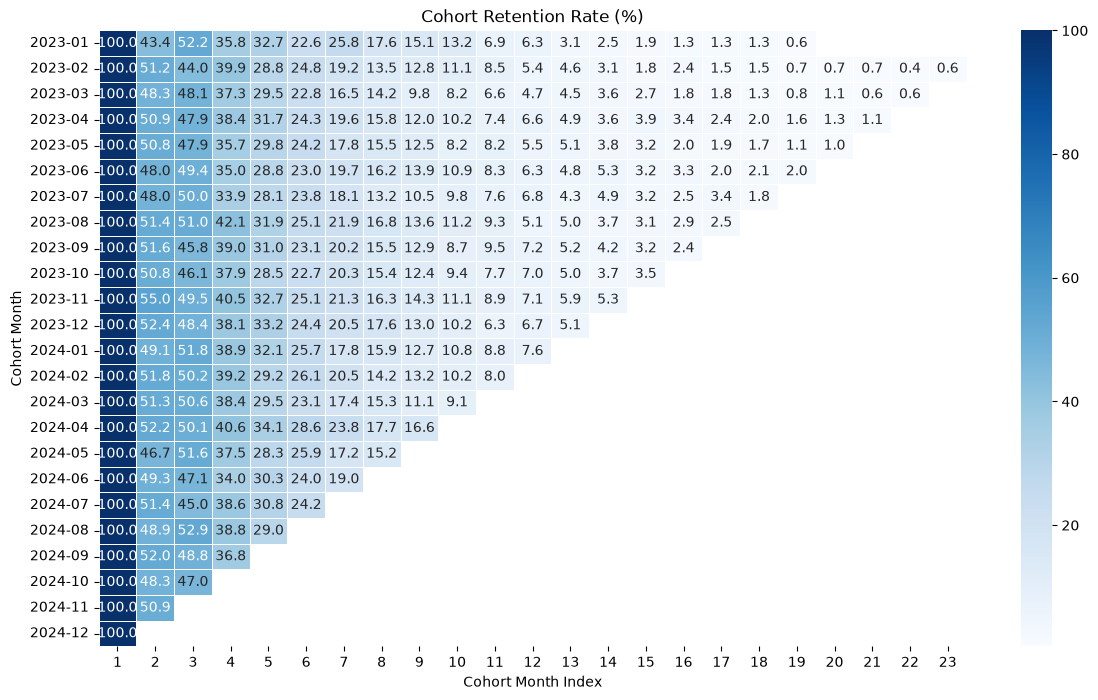

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Cohort Retention Rate (%)")
plt.xlabel("Cohort Month Index")
plt.ylabel("Cohort Month")

plt.show()

In [17]:
best_cohorts = (
    retention_matrix.iloc[:, 1:]
    .mean(axis=1)
    .sort_values(ascending=False)
)

best_cohorts.head(10)

cohort_month
2024-11    0.509346
2024-10    0.476841
2024-09    0.458435
2024-08    0.423962
2024-07    0.379929
2024-06    0.339293
2024-04    0.329588
2024-05    0.317728
2024-03    0.273204
2024-02    0.262639
Freq: M, dtype: float64

In [18]:
print("Average Month 2 Retention:",
      f"{retention_matrix[2].mean() * 100:.2f}%")

print("Average Month 3 Retention:",
      f"{retention_matrix[3].mean() * 100:.2f}%")

print("Average Month 4 Retention:",
      f"{retention_matrix[4].mean() * 100:.2f}%")

Average Month 2 Retention: 50.16%
Average Month 3 Retention: 48.87%
Average Month 4 Retention: 37.92%
